## Fovea
### Is it a key?

In [3]:
import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [4]:
!pip install -Uqq ddgs fastai
!pip uninstall -y fastprogress
!pip install "fastprogress==1.0.3"
from fastprogress import fastprogress
fastprogress.NO_BAR = True

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 69.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.7/240.7 kB 18.7 MB/s eta 0:00:00
Found existing installation: fastprogress 1.1.3
Uninstalling fastprogress-1.1.3:
  Successfully uninstalled fastprogress-1.1.3


In [5]:
import os
# check our data set is there
os.listdir('/kaggle/input/datasets/heartburn/leaked-keys/')

['valid', 'invalid']

In [7]:
from fastai.vision.all import *
valid_key_path =  '/kaggle/input/datasets/heartburn/leaked-keys/valid/'
invalid_key_path = '/kaggle/input/datasets/heartburn/leaked-keys/invalid'
failed = verify_images(get_image_files(valid_key_path))
failed.map(Path.unlink)
print(f"total of {len(failed)} invalid images in {valid_key_path}")
failed = verify_images(get_image_files(invalid_key_path))
failed.map(Path.unlink)
print(f"total of {len(failed)} invalid images in {invalid_key_path}")

total of 0 invalid images in /kaggle/input/datasets/heartburn/leaked-keys/valid/
total of 0 invalid images in /kaggle/input/datasets/heartburn/leaked-keys/invalid


In [8]:
get_y=lambda x: "invalid" if "invalid" in x.parent.parent.name else "valid"
get_y(Path('/kaggle/input/datasets/heartburn/leaked-keys/valid/1/1'))

get_training_label = lambda x: "invalid" if "invalid" in x.parent.parent.name else "valid"
path = Path('/kaggle/input/datasets/heartburn/leaked-keys')

In [ ]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_training_label,
    item_tfms=[Resize(512, method='pad', pad_mode=PadMode.Zeros)],
    batch_tfms=[]
).dataloaders(path, bs=8)

dls.show_batch(max_n=10)

Lets see how it does with the padding of zeros and resize of 512.

In [ ]:
learn = vision_learner(dls, resnet34, pretrained=True, metrics=error_rate)
learn.remove_cb(learn.cbs.filter(lambda x: x.__class__.__name__ == 'ProgressCallback')[0])
learn.fine_tune(10, cbs=CSVLogger())
'''
Results show a relatively innacurate training run. There was minimal real learning benefit past 3 runs. 
66% accuracy initially down to 73% for the final run, with the most accurate at 76%.

[0, 1.2172675132751465, 1.153378963470459, 0.34020617604255676, '00:23']
[0, 1.0836975574493408, 0.9421798586845398, 0.3711340129375458, '00:24']
[1, 1.0631271600723267, 0.7877123355865479, 0.3298968970775604, '00:23']
[2, 0.9578118324279785, 0.8047071099281311, 0.27835050225257874, '00:24']
[3, 0.9569419026374817, 1.0857962369918823, 0.2989690601825714, '00:24']
[4, 0.9106955528259277, 0.9331204295158386, 0.30927833914756775, '00:24']
[5, 0.7180835008621216, 0.7170403599739075, 0.2989690601825714, '00:23']
[6, 0.6160396337509155, 0.7559671998023987, 0.2886597812175751, '00:23']
[7, 0.5054051280021667, 0.6589996814727783, 0.2989690601825714, '00:23']
[8, 0.48990410566329956, 0.5718319416046143, 0.24742268025875092, '00:23']
[9, 0.40929099917411804, 0.6081179976463318, 0.27835050225257874, '00:24']
'''

And now with just padding in general... This kinda just fills it with its own image a few times, which shouldn't necessarily be an issue, if anything it might give it more data?

In [ ]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_training_label,
    item_tfms=[Resize(512, method='pad')],
    batch_tfms=[]
).dataloaders(path, bs=8)

dls.show_batch(max_n=10)

In [ ]:
learn = vision_learner(dls, resnet34, pretrained=True, metrics=error_rate)
learn.remove_cb(learn.cbs.filter(lambda x: x.__class__.__name__ == 'ProgressCallback')[0])
learn.fine_tune(10, cbs=CSVLogger())

'''
Improved performance here. Learning peaked at around the sixth iteration and acheived an 82% accuracy - reasonable!
Subsequent training ended up hovering around 80% accuracy. Therefore, I can surmize that padding without 
using the Padding.Zero setting is more accurate for this specific experiment. I think this is due to padding's default
behaviour using a 'mirror' of the image, which just increases the frequency that valid/invalid secrets are incorporated.

This beats cropping it, as we may lose the very part of training data that we need. Unlike traditional vision learning,
such as that of a bird/forest, taking away the actual secret incidentally by cropping would cause the data
to become invalid, rather than just 'harder' to identify (you can see identify a bird from a part of the bird,
but can't use a screenshot that has the secret cropped out of it).

[0, 1.3245829343795776, 0.7545505166053772, 0.2989690601825714, '00:28']
[0, 0.9561367630958557, 0.6363096833229065, 0.23711340129375458, '00:27']
[1, 0.8666336536407471, 0.8530787229537964, 0.3814432919025421, '00:27']
[2, 0.8636853694915771, 0.775465726852417, 0.27835050225257874, '00:28']
[3, 0.8129541873931885, 0.6775510311126709, 0.22680412232875824, '00:28']
[4, 0.7263489365577698, 0.6134542226791382, 0.24742268025875092, '00:27']
[5, 0.5820316672325134, 0.4546082615852356, 0.19587628543376923, '00:28']
[6, 0.433907687664032, 0.532484769821167, 0.1855670064687729, '00:27']
[7, 0.37757912278175354, 0.6732586026191711, 0.2164948433637619, '00:28']
[8, 0.29393354058265686, 0.5744597315788269, 0.20618556439876556, '00:27']
[9, 0.27146047353744507, 0.581489086151123, 0.2164948433637619, '00:28']
'''

What about a larger resize - sticking to the improve performance of regular padding?

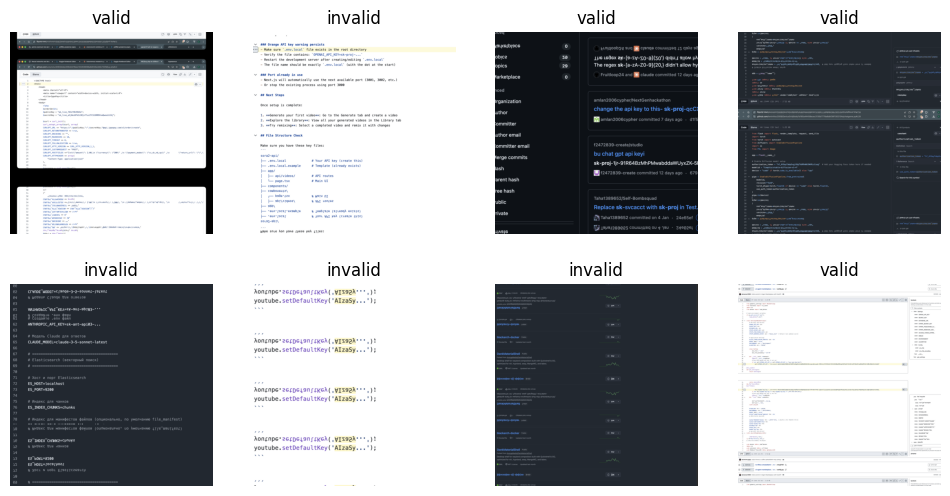

In [26]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_training_label,
    item_tfms=[Resize(1024, method='pad')],
    batch_tfms=[]
).dataloaders(path, bs=8)

dls.show_batch(max_n=10)

In [27]:
learn = vision_learner(dls, resnet34, pretrained=True, metrics=error_rate)
learn.remove_cb(learn.cbs.filter(lambda x: x.__class__.__name__ == 'ProgressCallback')[0])
learn.fine_tune(10, cbs=CSVLogger())
'''
So making my images larger (512 to 1024) doesn't seem to make much difference.
If anything, it gets worse here, so maybe the resize is damaging the quality
of the smaller images too much.

[0, 1.1534652709960938, 0.906426191329956, 0.36082473397254944, '00:35']
[0, 0.8127822279930115, 0.7181851863861084, 0.27835050225257874, '00:36']
[1, 0.8165367245674133, 0.9588363766670227, 0.34020617604255676, '00:36']
[2, 0.893031656742096, 1.0545357465744019, 0.3298968970775604, '00:35']
[3, 0.8281828761100769, 0.867970883846283, 0.3298968970775604, '00:36']
[4, 0.6962894201278687, 0.7232149243354797, 0.27835050225257874, '00:35']
[5, 0.5723240375518799, 0.5596204400062561, 0.24742268025875092, '00:36']
[6, 0.44200998544692993, 0.6210831999778748, 0.22680412232875824, '00:36']
[7, 0.38537830114364624, 0.7027066349983215, 0.27835050225257874, '00:38']
[8, 0.31277167797088623, 0.5986477136611938, 0.23711340129375458, '00:37']
[9, 0.2954860329627991, 0.6769066452980042, 0.2680412232875824, '00:37']
'''

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 213MB/s]


[0, 1.1534652709960938, 0.906426191329956, 0.36082473397254944, '00:35']
[0, 0.8127822279930115, 0.7181851863861084, 0.27835050225257874, '00:36']
[1, 0.8165367245674133, 0.9588363766670227, 0.34020617604255676, '00:36']
[2, 0.893031656742096, 1.0545357465744019, 0.3298968970775604, '00:35']
[3, 0.8281828761100769, 0.867970883846283, 0.3298968970775604, '00:36']
[4, 0.6962894201278687, 0.7232149243354797, 0.27835050225257874, '00:35']
[5, 0.5723240375518799, 0.5596204400062561, 0.24742268025875092, '00:36']
[6, 0.44200998544692993, 0.6210831999778748, 0.22680412232875824, '00:36']
[7, 0.38537830114364624, 0.7027066349983215, 0.27835050225257874, '00:38']
[8, 0.31277167797088623, 0.5986477136611938, 0.23711340129375458, '00:37']
[9, 0.2954860329627991, 0.6769066452980042, 0.2680412232875824, '00:37']


In [28]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_training_label,
    item_tfms=[Resize(1024, method='pad', pad_mode=PadMode.Zeros)],
    batch_tfms=[]
).dataloaders(path, bs=8)

I will try again, but rather than mirroring the padded content, I'll pad it with zeros and see if that changes the results. 

In [29]:
learn = vision_learner(dls, resnet34, pretrained=True, metrics=error_rate)
learn.remove_cb(learn.cbs.filter(lambda x: x.__class__.__name__ == 'ProgressCallback')[0])
learn.fine_tune(10, cbs=CSVLogger())

'''
Still pretty poor, better as it went on, but not great.

[0, 1.3359612226486206, 0.9057859182357788, 0.3505154550075531, '00:26']
[0, 0.965613603591919, 0.8191282153129578, 0.36082473397254944, '00:27']
[1, 0.9318797588348389, 0.7958654165267944, 0.3505154550075531, '00:28']
[2, 0.9683655500411987, 1.0445085763931274, 0.44329896569252014, '00:28']
[3, 1.0067486763000488, 1.261667251586914, 0.30927833914756775, '00:27']
[4, 0.8590190410614014, 0.8151019215583801, 0.3711340129375458, '00:28']
[5, 0.7104024291038513, 0.6218743324279785, 0.2680412232875824, '00:27']
[6, 0.6273471713066101, 0.7534789443016052, 0.2989690601825714, '00:27']
[7, 0.5995516777038574, 0.5434754490852356, 0.19587628543376923, '00:28']
[8, 0.5143299102783203, 0.4968615770339966, 0.2164948433637619, '00:27']
[9, 0.46682313084602356, 0.5292530655860901, 0.24742268025875092, '00:28']
'''

[0, 1.3359612226486206, 0.9057859182357788, 0.3505154550075531, '00:26']
[0, 0.965613603591919, 0.8191282153129578, 0.36082473397254944, '00:27']
[1, 0.9318797588348389, 0.7958654165267944, 0.3505154550075531, '00:28']
[2, 0.9683655500411987, 1.0445085763931274, 0.44329896569252014, '00:28']
[3, 1.0067486763000488, 1.261667251586914, 0.30927833914756775, '00:27']
[4, 0.8590190410614014, 0.8151019215583801, 0.3711340129375458, '00:28']
[5, 0.7104024291038513, 0.6218743324279785, 0.2680412232875824, '00:27']
[6, 0.6273471713066101, 0.7534789443016052, 0.2989690601825714, '00:27']
[7, 0.5995516777038574, 0.5434754490852356, 0.19587628543376923, '00:28']
[8, 0.5143299102783203, 0.4968615770339966, 0.2164948433637619, '00:27']
[9, 0.46682313084602356, 0.5292530655860901, 0.24742268025875092, '00:28']


Going to reduce the image resize to 256 now, and since we'll save on some processing power, up the epochs to 25. 

In [30]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_training_label,
    item_tfms=[Resize(256, method='pad')],
    batch_tfms=[]
).dataloaders(path, bs=8)

In [31]:
learn = vision_learner(dls, resnet34, pretrained=True, metrics=error_rate)
learn.remove_cb(learn.cbs.filter(lambda x: x.__class__.__name__ == 'ProgressCallback')[0])
learn.fine_tune(25, cbs=CSVLogger())

'''
Very nice! Closer to my goal of near 85% now. I will up it back to 512, increase
epochs to 50, and then repeat with size of 256 to see if the additional resizing
is worth it. Regular padding seems to vastly improve accuracy compared to
padding with Zeros.

[0, 1.1789677143096924, 1.1026822328567505, 0.39175257086753845, '00:19']
[0, 1.0158535242080688, 1.0149192810058594, 0.3298968970775604, '00:19']
[1, 0.820689857006073, 0.9827418327331543, 0.34020617604255676, '00:19']
[2, 0.7201284766197205, 0.7658541202545166, 0.3298968970775604, '00:19']
[3, 0.76351398229599, 1.1338216066360474, 0.3711340129375458, '00:19']
[4, 0.7521508932113647, 0.6998182535171509, 0.24742268025875092, '00:19']
[5, 0.655836284160614, 0.8307687640190125, 0.25773194432258606, '00:19']
[6, 0.6459324955940247, 0.92069411277771, 0.2886597812175751, '00:19']
[7, 0.6076089143753052, 0.6179310083389282, 0.2164948433637619, '00:19']
[8, 0.5184980034828186, 0.6775901317596436, 0.2886597812175751, '00:19']
[9, 0.5171887874603271, 0.608629584312439, 0.27835050225257874, '00:19']
[10, 0.4511207044124603, 0.9003394246101379, 0.27835050225257874, '00:19']
[11, 0.3992502689361572, 0.5481789708137512, 0.20618556439876556, '00:20']
[12, 0.3978859782218933, 0.5959411859512329, 0.23711340129375458, '00:19']
[13, 0.3227163255214691, 0.6034870147705078, 0.2164948433637619, '00:19']
[14, 0.29187726974487305, 0.7993931174278259, 0.24742268025875092, '00:19']
[15, 0.22733797132968903, 0.5647456049919128, 0.19587628543376923, '00:19']
[16, 0.20853862166404724, 0.6774186491966248, 0.22680412232875824, '00:19']
[17, 0.24627505242824554, 0.4302784204483032, 0.1340206116437912, '00:19']
[18, 0.2241756021976471, 0.47872835397720337, 0.1649484485387802, '00:19']
[19, 0.20936958491802216, 0.5306750535964966, 0.19587628543376923, '00:19']
[20, 0.17138341069221497, 0.4951823055744171, 0.15463916957378387, '00:20']
[21, 0.15065254271030426, 0.45313915610313416, 0.1340206116437912, '00:19']
[22, 0.12413216382265091, 0.46898630261421204, 0.15463916957378387, '00:19']
[23, 0.12287130951881409, 0.4703011214733124, 0.17525772750377655, '00:19']
[24, 0.1023290678858757, 0.48265981674194336, 0.17525772750377655, '00:19']
'''

[0, 1.1789677143096924, 1.1026822328567505, 0.39175257086753845, '00:19']
[0, 1.0158535242080688, 1.0149192810058594, 0.3298968970775604, '00:19']
[1, 0.820689857006073, 0.9827418327331543, 0.34020617604255676, '00:19']
[2, 0.7201284766197205, 0.7658541202545166, 0.3298968970775604, '00:19']
[3, 0.76351398229599, 1.1338216066360474, 0.3711340129375458, '00:19']
[4, 0.7521508932113647, 0.6998182535171509, 0.24742268025875092, '00:19']
[5, 0.655836284160614, 0.8307687640190125, 0.25773194432258606, '00:19']
[6, 0.6459324955940247, 0.92069411277771, 0.2886597812175751, '00:19']
[7, 0.6076089143753052, 0.6179310083389282, 0.2164948433637619, '00:19']
[8, 0.5184980034828186, 0.6775901317596436, 0.2886597812175751, '00:19']
[9, 0.5171887874603271, 0.608629584312439, 0.27835050225257874, '00:19']
[10, 0.4511207044124603, 0.9003394246101379, 0.27835050225257874, '00:19']
[11, 0.3992502689361572, 0.5481789708137512, 0.20618556439876556, '00:20']
[12, 0.3978859782218933, 0.5959411859512329, 0.23

In [32]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_training_label,
    item_tfms=[Resize(512, method='pad')],
    batch_tfms=[]
).dataloaders(path, bs=8)

learn = vision_learner(dls, resnet34, pretrained=True, metrics=error_rate)
learn.remove_cb(learn.cbs.filter(lambda x: x.__class__.__name__ == 'ProgressCallback')[0])
learn.fine_tune(50, cbs=CSVLogger())

'''
Interestingly, seems the larger resize came out worse than the smaller resize. 
One final test now, otherwise we'll have to settle with around 83%.

...
[45, 0.114924356341362, 0.5991830229759216, 0.1649484485387802, '00:21']
[46, 0.10905634611845016, 0.5674408078193665, 0.1855670064687729, '00:22']
[47, 0.1027940884232521, 0.5551737546920776, 0.1649484485387802, '00:22']
[48, 0.10177160799503326, 0.5664820075035095, 0.17525772750377655, '00:21']
[49, 0.07618480175733566, 0.5499458909034729, 0.17525772750377655, '00:22']
'''

[0, 1.1470905542373657, 0.9526250958442688, 0.3505154550075531, '00:22']
[0, 0.9184087514877319, 0.865436851978302, 0.30927833914756775, '00:22']
[1, 0.8431840538978577, 0.9150911569595337, 0.3298968970775604, '00:22']
[2, 0.6996883749961853, 0.7354359030723572, 0.2989690601825714, '00:22']
[3, 0.6628210544586182, 0.7746791243553162, 0.27835050225257874, '00:22']
[4, 0.6776258945465088, 0.7635950446128845, 0.2680412232875824, '00:22']
[5, 0.643755316734314, 0.7876542806625366, 0.25773194432258606, '00:22']
[6, 0.5956586003303528, 0.7191524505615234, 0.23711340129375458, '00:22']
[7, 0.565212070941925, 0.8493020534515381, 0.27835050225257874, '00:23']
[8, 0.5977446436882019, 0.665465772151947, 0.2886597812175751, '00:22']
[9, 0.547967791557312, 0.7861119508743286, 0.22680412232875824, '00:22']
[10, 0.4714217185974121, 0.7104527354240417, 0.22680412232875824, '00:22']
[11, 0.4459227919578552, 0.8561962246894836, 0.2989690601825714, '00:22']
[12, 0.5054252743721008, 0.7715781927108765, 0.

Size back down to 256, batch size up to 16, 50 runs. Modified seed too, just incase we've been hitting a lucky validation seed. Shouldn't affect the results.  

In [33]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=30),
    get_y=get_training_label,
    item_tfms=[Resize(256, method='pad')],
    batch_tfms=[]
).dataloaders(path, bs=16)

learn = vision_learner(dls, resnet34, pretrained=True, metrics=error_rate)
learn.remove_cb(learn.cbs.filter(lambda x: x.__class__.__name__ == 'ProgressCallback')[0])
learn.fine_tune(50, cbs=CSVLogger())

'''
Ugh........ Very different results. Was it the batch size change or the seed?
...
[41, 0.04081334173679352, 1.0707279443740845, 0.25773194432258606, '00:20']
[42, 0.041145358234643936, 1.0231026411056519, 0.2886597812175751, '00:20']
[43, 0.047315564006567, 0.9914868474006653, 0.25773194432258606, '00:20']
[44, 0.05130709335207939, 1.0206637382507324, 0.2680412232875824, '00:20']
[45, 0.04695335030555725, 1.0244392156600952, 0.27835050225257874, '00:21']
[46, 0.04764517396688461, 1.0042033195495605, 0.24742268025875092, '00:21']
[47, 0.04215262830257416, 1.002761960029602, 0.25773194432258606, '00:21']
[48, 0.036247823387384415, 1.0250375270843506, 0.30927833914756775, '00:20']
[49, 0.03465935215353966, 0.9785423874855042, 0.2680412232875824, '00:21']
'''


[0, 1.329443097114563, 1.0426857471466064, 0.3298968970775604, '00:21']
[0, 1.0034993886947632, 1.1917520761489868, 0.3711340129375458, '00:20']
[1, 0.8315615057945251, 1.0749106407165527, 0.34020617604255676, '00:20']
[2, 0.7102590799331665, 0.9971591234207153, 0.3814432919025421, '00:21']
[3, 0.6427732706069946, 0.9604106545448303, 0.3814432919025421, '00:21']
[4, 0.5506424307823181, 1.0242425203323364, 0.3195876181125641, '00:21']
[5, 0.5089911818504333, 1.1118171215057373, 0.3814432919025421, '00:20']
[6, 0.4859824776649475, 1.5598459243774414, 0.36082473397254944, '00:21']
[7, 0.4214102327823639, 1.3210759162902832, 0.36082473397254944, '00:21']
[8, 0.339432954788208, 1.4034596681594849, 0.36082473397254944, '00:21']
[9, 0.3518045246601105, 1.7510164976119995, 0.3814432919025421, '00:20']
[10, 0.36363905668258667, 1.5463261604309082, 0.3195876181125641, '00:20']
[11, 0.3816153109073639, 1.4825718402862549, 0.34020617604255676, '00:20']
[12, 0.34028613567352295, 1.415520429611206, 

Batch size back to 8. Seed remaining at 30.

In [9]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=30),
    get_y=get_training_label,
    item_tfms=[Resize(256, method='pad')],
    batch_tfms=[]
).dataloaders(path, bs=8)

learn = vision_learner(dls, resnet34, pretrained=True, metrics=error_rate)
learn.remove_cb(learn.cbs.filter(lambda x: x.__class__.__name__ == 'ProgressCallback')[0])
learn.fine_tune(30, cbs=CSVLogger())

'''
Varying results massively with different seeds.

[0, 1.2242279052734375, 1.1599401235580444, 0.4020618498325348, '00:26']
[0, 1.0048030614852905, 0.8668988943099976, 0.3298968970775604, '00:27']
[1, 0.908842921257019, 0.9642831683158875, 0.36082473397254944, '00:26']
[2, 0.8550211787223816, 0.7847016453742981, 0.3195876181125641, '00:26']
[3, 0.7521104216575623, 1.0662014484405518, 0.36082473397254944, '00:26']
[4, 0.6789453625679016, 1.1950228214263916, 0.36082473397254944, '00:27']
[5, 0.6524702906608582, 1.217775821685791, 0.36082473397254944, '00:26']
[6, 0.6422083973884583, 1.120570182800293, 0.34020617604255676, '00:26']
[7, 0.7121591567993164, 1.1268774271011353, 0.41237112879753113, '00:26']
[8, 0.5906118154525757, 1.2096436023712158, 0.3814432919025421, '00:27']
[9, 0.5071706771850586, 0.8610291481018066, 0.27835050225257874, '00:26']
[10, 0.45617324113845825, 1.0220837593078613, 0.3298968970775604, '00:27']
[11, 0.4392072260379791, 1.0494670867919922, 0.2989690601825714, '00:26']
[12, 0.3589811325073242, 1.044788122177124, 0.27835050225257874, '00:26']
[13, 0.32796692848205566, 0.9701767563819885, 0.2680412232875824, '00:26']
[14, 0.3409700393676758, 1.3794084787368774, 0.3195876181125641, '00:26']
[15, 0.32706543803215027, 0.9449820518493652, 0.2886597812175751, '00:26']
[16, 0.32533279061317444, 1.2058407068252563, 0.34020617604255676, '00:26']
[17, 0.23889869451522827, 0.9344733357429504, 0.2680412232875824, '00:27']
[18, 0.21063494682312012, 0.9923866391181946, 0.23711340129375458, '00:27']
[19, 0.14965541660785675, 0.9412791728973389, 0.22680412232875824, '00:26']
[20, 0.1623985320329666, 0.8219045996665955, 0.24742268025875092, '00:26']
[21, 0.18281225860118866, 0.8071773648262024, 0.25773194432258606, '00:27']
[22, 0.1599501073360443, 0.9678398370742798, 0.2886597812175751, '00:27']
[23, 0.1439061462879181, 1.139575719833374, 0.30927833914756775, '00:27']
[24, 0.10896001756191254, 1.070033311843872, 0.30927833914756775, '00:26']
[25, 0.12931017577648163, 0.9584487676620483, 0.2989690601825714, '00:27']
[26, 0.11212866753339767, 0.911369800567627, 0.23711340129375458, '00:26']
[27, 0.14152005314826965, 0.9563899040222168, 0.23711340129375458, '00:26']
[28, 0.10179079324007034, 0.9412754774093628, 0.25773194432258606, '00:26']
[29, 0.09400731325149536, 0.9097940325737, 0.2680412232875824, '00:26']
'''

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 186MB/s]


[0, 1.2242279052734375, 1.1599401235580444, 0.4020618498325348, '00:26']
[0, 1.0048030614852905, 0.8668988943099976, 0.3298968970775604, '00:27']
[1, 0.908842921257019, 0.9642831683158875, 0.36082473397254944, '00:26']
[2, 0.8550211787223816, 0.7847016453742981, 0.3195876181125641, '00:26']
[3, 0.7521104216575623, 1.0662014484405518, 0.36082473397254944, '00:26']
[4, 0.6789453625679016, 1.1950228214263916, 0.36082473397254944, '00:27']
[5, 0.6524702906608582, 1.217775821685791, 0.36082473397254944, '00:26']
[6, 0.6422083973884583, 1.120570182800293, 0.34020617604255676, '00:26']
[7, 0.7121591567993164, 1.1268774271011353, 0.41237112879753113, '00:26']
[8, 0.5906118154525757, 1.2096436023712158, 0.3814432919025421, '00:27']
[9, 0.5071706771850586, 0.8610291481018066, 0.27835050225257874, '00:26']
[10, 0.45617324113845825, 1.0220837593078613, 0.3298968970775604, '00:27']
[11, 0.4392072260379791, 1.0494670867919922, 0.2989690601825714, '00:26']
[12, 0.3589811325073242, 1.044788122177124, 

In [10]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=60),
    get_y=get_training_label,
    item_tfms=[Resize(256, method='pad')],
    batch_tfms=[]
).dataloaders(path, bs=8)

learn = vision_learner(dls, resnet34, pretrained=True, metrics=error_rate)
learn.remove_cb(learn.cbs.filter(lambda x: x.__class__.__name__ == 'ProgressCallback')[0])
learn.fine_tune(30, cbs=CSVLogger())

'''
Down to about 80% here, not bad.


[0, 1.1976958513259888, 1.0756210088729858, 0.3814432919025421, '00:25']
[0, 0.9910241961479187, 0.9141191840171814, 0.3195876181125641, '00:24']
[1, 0.9363278746604919, 0.7991397380828857, 0.2989690601825714, '00:24']
[2, 0.8216830492019653, 0.925363302230835, 0.3298968970775604, '00:24']
[3, 0.6833200454711914, 0.8865757584571838, 0.2886597812175751, '00:24']
[4, 0.6974233984947205, 0.8435885310173035, 0.2886597812175751, '00:24']
[5, 0.7575714588165283, 1.2087740898132324, 0.3195876181125641, '00:24']
[6, 0.6650708913803101, 0.8522160053253174, 0.2989690601825714, '00:25']
[7, 0.6638407111167908, 0.7696840763092041, 0.24742268025875092, '00:24']
[8, 0.5076249837875366, 0.7510191202163696, 0.30927833914756775, '00:25']
[9, 0.4716412425041199, 0.9915179014205933, 0.3505154550075531, '00:24']
[10, 0.4610622525215149, 1.314224123954773, 0.3298968970775604, '00:25']
[11, 0.4169413447380066, 0.8960253000259399, 0.25773194432258606, '00:25']
[12, 0.36955779790878296, 1.0200258493423462, 0.30927833914756775, '00:25']
[13, 0.32160893082618713, 1.0933098793029785, 0.30927833914756775, '00:25']
[14, 0.33014732599258423, 0.6537967920303345, 0.20618556439876556, '00:24']
[15, 0.2793131470680237, 0.8582866787910461, 0.2680412232875824, '00:24']
[16, 0.3046562373638153, 0.6297361850738525, 0.25773194432258606, '00:24']
[17, 0.2740541100502014, 0.8427272439002991, 0.23711340129375458, '00:25']
[18, 0.23455598950386047, 0.8840526342391968, 0.22680412232875824, '00:24']
[19, 0.19557267427444458, 1.0187379121780396, 0.2989690601825714, '00:24']
[20, 0.23958063125610352, 0.7025765776634216, 0.23711340129375458, '00:24']
[21, 0.1821441948413849, 0.7111936807632446, 0.24742268025875092, '00:23']
[22, 0.1526310294866562, 0.7879891991615295, 0.23711340129375458, '00:19']
[23, 0.14487405121326447, 0.7211359739303589, 0.22680412232875824, '00:19']
[24, 0.10555336624383926, 0.8485033512115479, 0.2164948433637619, '00:20']
[25, 0.09655104577541351, 0.7997545003890991, 0.19587628543376923, '00:19']
[26, 0.10102791339159012, 0.7535287737846375, 0.20618556439876556, '00:20']
[27, 0.10173244774341583, 0.8145563006401062, 0.22680412232875824, '00:20']
[28, 0.12873367965221405, 0.7583620548248291, 0.19587628543376923, '00:19']
[29, 0.09981490671634674, 0.8105771541595459, 0.2164948433637619, '00:19']
'''

[0, 1.1976958513259888, 1.0756210088729858, 0.3814432919025421, '00:25']
[0, 0.9910241961479187, 0.9141191840171814, 0.3195876181125641, '00:24']
[1, 0.9363278746604919, 0.7991397380828857, 0.2989690601825714, '00:24']
[2, 0.8216830492019653, 0.925363302230835, 0.3298968970775604, '00:24']
[3, 0.6833200454711914, 0.8865757584571838, 0.2886597812175751, '00:24']
[4, 0.6974233984947205, 0.8435885310173035, 0.2886597812175751, '00:24']
[5, 0.7575714588165283, 1.2087740898132324, 0.3195876181125641, '00:24']
[6, 0.6650708913803101, 0.8522160053253174, 0.2989690601825714, '00:25']
[7, 0.6638407111167908, 0.7696840763092041, 0.24742268025875092, '00:24']
[8, 0.5076249837875366, 0.7510191202163696, 0.30927833914756775, '00:25']
[9, 0.4716412425041199, 0.9915179014205933, 0.3505154550075531, '00:24']
[10, 0.4610622525215149, 1.314224123954773, 0.3298968970775604, '00:25']
[11, 0.4169413447380066, 0.8960253000259399, 0.25773194432258606, '00:25']
[12, 0.36955779790878296, 1.0200258493423462, 0.

In [37]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=50),
    get_y=get_training_label,
    item_tfms=[Resize(256, method='pad')],
    batch_tfms=[]
).dataloaders(path, bs=8)

learn = vision_learner(dls, resnet34, pretrained=True, metrics=error_rate)
learn.remove_cb(learn.cbs.filter(lambda x: x.__class__.__name__ == 'ProgressCallback')[0])
learn.fine_tune(30, cbs=CSVLogger())

'''
Different seed (50) got down to about 81%. Decent.

[0, 1.1927562952041626, 1.244996428489685, 0.3711340129375458, '00:20']
[0, 1.0476609468460083, 0.9819203019142151, 0.3505154550075531, '00:20']
[1, 0.9050007462501526, 0.8769193887710571, 0.30927833914756775, '00:20']
[2, 0.8735243082046509, 0.8686738014221191, 0.3195876181125641, '00:20']
[3, 0.7788133025169373, 0.915886640548706, 0.3298968970775604, '00:20']
[4, 0.6668878793716431, 1.0757607221603394, 0.30927833914756775, '00:20']
[5, 0.7014576196670532, 0.8560073971748352, 0.3298968970775604, '00:21']
[6, 0.6547269821166992, 0.6379756927490234, 0.23711340129375458, '00:20']
[7, 0.640539824962616, 0.9878528118133545, 0.36082473397254944, '00:20']
[8, 0.6296337246894836, 0.8173858523368835, 0.2680412232875824, '00:20']
[9, 0.5167232155799866, 0.9154165387153625, 0.3195876181125641, '00:20']
[10, 0.47857826948165894, 0.8726061582565308, 0.2680412232875824, '00:20']
[11, 0.4446202516555786, 0.6492589712142944, 0.24742268025875092, '00:20']
[12, 0.33795300126075745, 0.8003306984901428, 0.2680412232875824, '00:21']
[13, 0.28538912534713745, 1.2321162223815918, 0.39175257086753845, '00:21']
[14, 0.33594000339508057, 0.848957896232605, 0.24742268025875092, '00:20']
[15, 0.2779971957206726, 0.5626659393310547, 0.24742268025875092, '00:21']
[16, 0.23724780976772308, 0.6304389238357544, 0.22680412232875824, '00:20']
[17, 0.21928000450134277, 0.7017484307289124, 0.22680412232875824, '00:20']
[18, 0.1825779229402542, 0.8468212485313416, 0.2164948433637619, '00:21']
[19, 0.18290255963802338, 0.6812264919281006, 0.2164948433637619, '00:20']
[20, 0.19432814419269562, 0.5986761450767517, 0.2164948433637619, '00:21']
[21, 0.1446678638458252, 0.7462131381034851, 0.24742268025875092, '00:21']
[22, 0.16348350048065186, 0.748691201210022, 0.2164948433637619, '00:20']
[23, 0.16964878141880035, 0.6940209865570068, 0.2164948433637619, '00:20']
[24, 0.15398062765598297, 0.6854667067527771, 0.19587628543376923, '00:20']
[25, 0.12484241276979446, 0.6751468181610107, 0.19587628543376923, '00:20']
[26, 0.10552451759576797, 0.6669726967811584, 0.1855670064687729, '00:21']
[27, 0.09447064250707626, 0.6902660727500916, 0.1855670064687729, '00:21']
[28, 0.1017136201262474, 0.6738743782043457, 0.19587628543376923, '00:20']
[29, 0.10728973150253296, 0.7174288034439087, 0.19587628543376923, '00:20']
'''

[0, 1.1927562952041626, 1.244996428489685, 0.3711340129375458, '00:20']
[0, 1.0476609468460083, 0.9819203019142151, 0.3505154550075531, '00:20']
[1, 0.9050007462501526, 0.8769193887710571, 0.30927833914756775, '00:20']
[2, 0.8735243082046509, 0.8686738014221191, 0.3195876181125641, '00:20']
[3, 0.7788133025169373, 0.915886640548706, 0.3298968970775604, '00:20']
[4, 0.6668878793716431, 1.0757607221603394, 0.30927833914756775, '00:20']
[5, 0.7014576196670532, 0.8560073971748352, 0.3298968970775604, '00:21']
[6, 0.6547269821166992, 0.6379756927490234, 0.23711340129375458, '00:20']
[7, 0.640539824962616, 0.9878528118133545, 0.36082473397254944, '00:20']
[8, 0.6296337246894836, 0.8173858523368835, 0.2680412232875824, '00:20']
[9, 0.5167232155799866, 0.9154165387153625, 0.3195876181125641, '00:20']
[10, 0.47857826948165894, 0.8726061582565308, 0.2680412232875824, '00:20']
[11, 0.4446202516555786, 0.6492589712142944, 0.24742268025875092, '00:20']
[12, 0.33795300126075745, 0.8003306984901428, 

In [11]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=2),
    get_y=get_training_label,
    item_tfms=[Resize(256, method='pad')],
    batch_tfms=[]
).dataloaders(path, bs=8)

learn = vision_learner(dls, resnet34, pretrained=True, metrics=error_rate)
learn.remove_cb(learn.cbs.filter(lambda x: x.__class__.__name__ == 'ProgressCallback')[0])
learn.fine_tune(30, cbs=CSVLogger())

'''
Again around 80%

[0, 1.1197072267532349, 0.6819724440574646, 0.25773194432258606, '00:20']
[0, 1.067833423614502, 0.7148593068122864, 0.30927833914756775, '00:20']
[1, 1.0007652044296265, 0.7269200682640076, 0.22680412232875824, '00:20']
[2, 0.8064115047454834, 0.5777379870414734, 0.25773194432258606, '00:20']
[3, 0.737967848777771, 0.6530517339706421, 0.2886597812175751, '00:20']
[4, 0.7347678542137146, 0.7596198916435242, 0.24742268025875092, '00:20']
[5, 0.6229850649833679, 0.883324146270752, 0.24742268025875092, '00:19']
[6, 0.6188468337059021, 1.0585945844650269, 0.2886597812175751, '00:20']
[7, 0.6190933585166931, 0.6766570806503296, 0.25773194432258606, '00:20']
[8, 0.5560082793235779, 0.6481837630271912, 0.25773194432258606, '00:20']
[9, 0.46682673692703247, 1.1034667491912842, 0.3195876181125641, '00:20']
[10, 0.5526569485664368, 0.8180435299873352, 0.30927833914756775, '00:20']
[11, 0.46399542689323425, 0.6160387396812439, 0.22680412232875824, '00:20']
[12, 0.44846946001052856, 0.5508283376693726, 0.22680412232875824, '00:20']
[13, 0.3838784098625183, 0.6739128232002258, 0.2164948433637619, '00:20']
[14, 0.35318538546562195, 0.8065754175186157, 0.20618556439876556, '00:20']
[15, 0.3190265893936157, 0.4887710213661194, 0.20618556439876556, '00:20']
[16, 0.35187485814094543, 0.6514837145805359, 0.2164948433637619, '00:19']
[17, 0.3191581666469574, 0.5365028977394104, 0.1649484485387802, '00:20']
[18, 0.22767896950244904, 0.624364972114563, 0.25773194432258606, '00:20']
[19, 0.19361872971057892, 0.6766749620437622, 0.22680412232875824, '00:20']
[20, 0.17144717276096344, 0.8057246208190918, 0.25773194432258606, '00:20']
[21, 0.15620799362659454, 0.6353887319564819, 0.23711340129375458, '00:20']
[22, 0.1549406200647354, 0.6947197914123535, 0.2164948433637619, '00:20']
[23, 0.14943376183509827, 0.6495975852012634, 0.2164948433637619, '00:20']
[24, 0.13766813278198242, 0.64497971534729, 0.2164948433637619, '00:20']
[25, 0.11314041912555695, 0.6364265084266663, 0.25773194432258606, '00:20']
[26, 0.11767617613077164, 0.735188901424408, 0.24742268025875092, '00:20']
[27, 0.13568711280822754, 0.8175560832023621, 0.23711340129375458, '00:20']
[28, 0.10981053858995438, 0.6625238060951233, 0.2164948433637619, '00:20']
[29, 0.1067681834101677, 0.6109560132026672, 0.20618556439876556, '00:20']
'''

[0, 1.1197072267532349, 0.6819724440574646, 0.25773194432258606, '00:20']
[0, 1.067833423614502, 0.7148593068122864, 0.30927833914756775, '00:20']
[1, 1.0007652044296265, 0.7269200682640076, 0.22680412232875824, '00:20']
[2, 0.8064115047454834, 0.5777379870414734, 0.25773194432258606, '00:20']
[3, 0.737967848777771, 0.6530517339706421, 0.2886597812175751, '00:20']
[4, 0.7347678542137146, 0.7596198916435242, 0.24742268025875092, '00:20']
[5, 0.6229850649833679, 0.883324146270752, 0.24742268025875092, '00:19']
[6, 0.6188468337059021, 1.0585945844650269, 0.2886597812175751, '00:20']
[7, 0.6190933585166931, 0.6766570806503296, 0.25773194432258606, '00:20']
[8, 0.5560082793235779, 0.6481837630271912, 0.25773194432258606, '00:20']
[9, 0.46682673692703247, 1.1034667491912842, 0.3195876181125641, '00:20']
[10, 0.5526569485664368, 0.8180435299873352, 0.30927833914756775, '00:20']
[11, 0.46399542689323425, 0.6160387396812439, 0.22680412232875824, '00:20']
[12, 0.44846946001052856, 0.550828337669

In [13]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_training_label,
    item_tfms=[Resize(256, method='pad')],
    batch_tfms=[]
).dataloaders(path, bs=8)

learn = vision_learner(dls, resnet34, pretrained=True, metrics=error_rate)
learn.remove_cb(learn.cbs.filter(lambda x: x.__class__.__name__ == 'ProgressCallback')[0])
learn.fine_tune(25, cbs=CSVLogger())

'''
Looks like this seed is consistently closest to a decent result. Let's just go with this.

[0, 1.236669659614563, 0.9187615513801575, 0.36082473397254944, '00:20']
[0, 0.9267573952674866, 0.8395571112632751, 0.3195876181125641, '00:20']
[1, 0.8228277564048767, 0.7845169305801392, 0.2680412232875824, '00:20']
[2, 0.7971404194831848, 0.834113597869873, 0.3298968970775604, '00:20']
[3, 0.7750358581542969, 0.7054396867752075, 0.22680412232875824, '00:20']
[4, 0.7165107131004333, 0.9960511326789856, 0.3505154550075531, '00:20']
[5, 0.6995813846588135, 0.7122398614883423, 0.23711340129375458, '00:21']
[6, 0.6715748310089111, 1.0525051355361938, 0.2680412232875824, '00:20']
[7, 0.5908002853393555, 0.795629620552063, 0.23711340129375458, '00:20']
[8, 0.4879629611968994, 0.7753763198852539, 0.23711340129375458, '00:19']
[9, 0.45641645789146423, 0.5815909504890442, 0.2164948433637619, '00:20']
[10, 0.4133152663707733, 0.6659971475601196, 0.2680412232875824, '00:19']
[11, 0.3424927294254303, 0.6917301416397095, 0.25773194432258606, '00:20']
[12, 0.3375360071659088, 0.5840014219284058, 0.2164948433637619, '00:20']
[13, 0.3072489798069, 0.7665510177612305, 0.2680412232875824, '00:19']
[14, 0.23658087849617004, 0.8571029901504517, 0.2164948433637619, '00:19']
[15, 0.23985445499420166, 0.7641627788543701, 0.24742268025875092, '00:19']
[16, 0.23366346955299377, 0.8374096751213074, 0.25773194432258606, '00:20']
[17, 0.25184166431427, 0.7196531891822815, 0.23711340129375458, '00:19']
[18, 0.23706404864788055, 0.6543477773666382, 0.23711340129375458, '00:19']
[19, 0.18476927280426025, 0.6594062447547913, 0.2164948433637619, '00:19']
[20, 0.1508538484573364, 0.5824397206306458, 0.17525772750377655, '00:20']
[21, 0.10642736405134201, 0.6309342980384827, 0.19587628543376923, '00:19']
[22, 0.11462797969579697, 0.5858234167098999, 0.17525772750377655, '00:19']
[23, 0.22510705888271332, 0.6402482390403748, 0.17525772750377655, '00:19']
[24, 0.17059722542762756, 0.6495398879051208, 0.1855670064687729, '00:20']
'''

[0, 1.236669659614563, 0.9187615513801575, 0.36082473397254944, '00:20']
[0, 0.9267573952674866, 0.8395571112632751, 0.3195876181125641, '00:20']
[1, 0.8228277564048767, 0.7845169305801392, 0.2680412232875824, '00:20']
[2, 0.7971404194831848, 0.834113597869873, 0.3298968970775604, '00:20']
[3, 0.7750358581542969, 0.7054396867752075, 0.22680412232875824, '00:20']
[4, 0.7165107131004333, 0.9960511326789856, 0.3505154550075531, '00:20']
[5, 0.6995813846588135, 0.7122398614883423, 0.23711340129375458, '00:21']
[6, 0.6715748310089111, 1.0525051355361938, 0.2680412232875824, '00:20']
[7, 0.5908002853393555, 0.795629620552063, 0.23711340129375458, '00:20']
[8, 0.4879629611968994, 0.7753763198852539, 0.23711340129375458, '00:19']
[9, 0.45641645789146423, 0.5815909504890442, 0.2164948433637619, '00:20']
[10, 0.4133152663707733, 0.6659971475601196, 0.2680412232875824, '00:19']
[11, 0.3424927294254303, 0.6917301416397095, 0.25773194432258606, '00:20']
[12, 0.3375360071659088, 0.5840014219284058, 

In [42]:
is_valid,_,probs = learn.predict(PILImage.create('/kaggle/input/datasets/heartburn/checking-keys/valid_1.png'))
print(f"Result: {is_valid}")
print(f"Confidence level: {probs[1]*100:.2f}% that this is a real key.")
is_valid,_,probs = learn.predict(PILImage.create('/kaggle/input/datasets/heartburn/checking-keys/valid_2.png'))
print(f"Result: {is_valid}")
print(f"Confidence level: {probs[1]*100:.2f}% that this is a real key.")
is_valid,_,probs = learn.predict(PILImage.create('/kaggle/input/datasets/heartburn/checking-keys/invalid_1.png'))
print(f"Result: {is_valid}")
print(f"Confidence level: {probs[1]*100:.2f}% that this is a real key.")
is_valid,_,probs = learn.predict(PILImage.create('/kaggle/input/datasets/heartburn/checking-keys/invalid_2.png'))
print(f"Result: {is_valid}")
print(f"Confidence level: {probs[1]*100:.2f}% that this is a real key.")
is_valid,_,probs = learn.predict(PILImage.create('/kaggle/input/datasets/heartburn/checking-keys/invalid_3.png'))
print(f"Result: {is_valid}")
print(f"Confidence level: {probs[1]*100:.2f}% that this is a real key.")


'''
It got this small sample of 5 correct. Nice!

Result: valid
Confidence level: 77.40% that this is a real key.
Result: valid
Confidence level: 95.08% that this is a real key.
Result: invalid
Confidence level: 22.26% that this is a real key.
Result: invalid
Confidence level: 35.33% that this is a real key.
Result: invalid
Confidence level: 45.24% that this is a real key.
'''

Result: valid
Confidence level: 77.40% that this is a real key.
Result: valid
Confidence level: 95.08% that this is a real key.
Result: invalid
Confidence level: 22.26% that this is a real key.
Result: invalid
Confidence level: 35.33% that this is a real key.
Result: invalid
Confidence level: 45.24% that this is a real key.


In [46]:
learn.export('fovea_model.pkl')